# Solver — Equazione del Calore 2D

**Task 4 & 5** — Fattorizzazione di Cholesky, soluzione del sistema lineare, analisi comparativa ordinamento naturale vs nested dissection.

Il notebook:
1. Legge `A.txt` e `rhs.txt` prodotti da `task3_assemble`
2. Calcola $-A = LL^T$ con CHOLMOD
3. Risolve $Au = b$ con `spsolve_triangular`
4. Per $N \in \{32, 64, 128, 256, 512\}$: confronta tempi e fill-in (`nnz(L)`) per i due ordinamenti
5. Produce spy plot, heatmap della soluzione e grafici log-log

In [1]:
# ── Cella 0 — Dipendenze ─────────────────────────────────────────────────────
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import os
import subprocess
from pathlib import Path
from sksparse.cholmod import cholesky
from scipy.sparse import csc_matrix, tril

# Cartella radice del progetto (il notebook si trova in notebook/)
ROOT = Path("../").resolve()
OUTPUT = ROOT / "output"

print(f"Root del progetto: {ROOT}")
print(f"Cartella output:   {OUTPUT}")

Root del progetto: /mnt/Dati/UNIVERSITY/INFORMATICA CON LABORATORIO 6CFU/Equazione-del-calore-2D-e-riordinamento-nelle-fattorizzazioni-Cholesky
Cartella output:   /mnt/Dati/UNIVERSITY/INFORMATICA CON LABORATORIO 6CFU/Equazione-del-calore-2D-e-riordinamento-nelle-fattorizzazioni-Cholesky/output


In [2]:
# ── Cella 1 — Funzioni di lettura ─────────────────────────────────────────────

def read_A(path):
    """
    Legge il file A.txt nel formato sparso (i j val) e restituisce
    una scipy.sparse.csc_matrix.
    Il file contiene sia (i,j,v) sia (j,i,v) per la simmetria;
    scipy somma automaticamente le entrate duplicate.
    """
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    rows = data[:, 0].astype(int)
    cols = data[:, 1].astype(int)
    vals = data[:, 2]
    n = max(rows.max(), cols.max()) + 1
    A = sp.coo_matrix((vals, (rows, cols)), shape=(n, n))
    return A.tocsc()


def read_rhs(path):
    """Legge il vettore termine noto b da rhs.txt."""
    return np.loadtxt(path)


def read_coords(path):
    """
    Legge coords.txt (id, i, j, x, y) e restituisce due array:
    xs[k], ys[k] = coordinate fisiche del nodo k.
    """
    data = np.loadtxt(path)
    n = int(data[:, 0].max()) + 1
    xs = np.zeros(n)
    ys = np.zeros(n)
    for row in data:
        k = int(row[0])
        xs[k] = row[3]
        ys[k] = row[4]
    return xs, ys


print("Funzioni di lettura definite.")

Funzioni di lettura definite.


In [3]:
# ── Cella 2 — Fattorizzazione di Cholesky ─────────────────────────────────────
#
# La matrice A è definita NEGATIVA (−∆ discretizzato con segno negativo).
# Quindi fattorizziamo −A = LL^T con L triangolare inferiore.
# CHOLMOD con order='natural' rispetta l'ordinamento già presente in A.

def my_cholesky(A):
    """
    Calcola la fattorizzazione di Cholesky di A (deve essere definita positiva).
    Restituisce L triangolare inferiore come csc_matrix.
    Uso: my_cholesky(-A) poiché A è definita negativa.
    """
    factor = cholesky(A, order="natural")
    return csc_matrix(factor[0])


print("Funzione my_cholesky definita.")

Funzione my_cholesky definita.


In [4]:
# ── Cella 3 — Funzione solve completa ─────────────────────────────────────────
#
# Risolve Au = b con A definita negativa:
#   1. Fattorizza −A = L L^T
#   2. Risolve L y = −b  (forward substitution)
#   3. Risolve L^T u = y  (backward substitution)
# Nota: Au = b  ⟺  (−A)(−u) = b  ⟺  L L^T (−u) = b
# Quindi risolviamo L L^T z = b e poi u = −z... ma è più semplice:
# Au = b  ⟺  (−A) u = −b ⟺  L L^T u = −b

def solve(A, b):
    """
    Risolve Au = b con A definita negativa.
    Restituisce la soluzione u e il fattore L.
    """
    neg_A = (-A).tocsc()
    L = my_cholesky(neg_A)          # −A = L L^T
    Lt = L.T.tocsc()
    neg_b = -b
    # Risolvi L y = −b
    y = spla.spsolve_triangular(L, neg_b, lower=True)
    # Risolvi L^T u = y
    u = spla.spsolve_triangular(Lt, y, lower=False)
    return u, L


print("Funzione solve definita.")

Funzione solve definita.


In [5]:
# ── Cella 4 — Test con N=4 (output già presenti) ──────────────────────────────

A = read_A(OUTPUT / "A.txt")
b = read_rhs(OUTPUT / "rhs.txt")
xs, ys = read_coords(OUTPUT / "coords.txt")

print(f"Dimensione A: {A.shape}, nnz(A) = {A.nnz}")
print(f"Dimensione b: {b.shape}")

u, L = solve(A, b)

print(f"nnz(L) = {L.nnz}")
print(f"\nSoluzione u (primi 16 nodi):")
print(np.round(u, 6))

# Verifica residuo
residuo = np.linalg.norm(A @ u - b) / np.linalg.norm(b)
print(f"\nResiduo relativo ||Au - b|| / ||b|| = {residuo:.2e}")

Dimensione A: (16, 16), nnz(A) = 64
Dimensione b: (16,)
nnz(L) = 67

Soluzione u (primi 16 nodi):
[ 4.49329e-01  7.86540e-02 -3.18970e-02 -1.33950e-02  6.24960e-02
 -4.11640e-02 -1.61260e-02 -5.56100e-03 -2.18390e-02 -8.07400e-03
 -2.45700e-03 -7.95000e-04 -2.41700e-03 -6.47000e-04 -1.43000e-04
 -4.00000e-05]

Residuo relativo ||Au - b|| / ||b|| = 5.46e-01


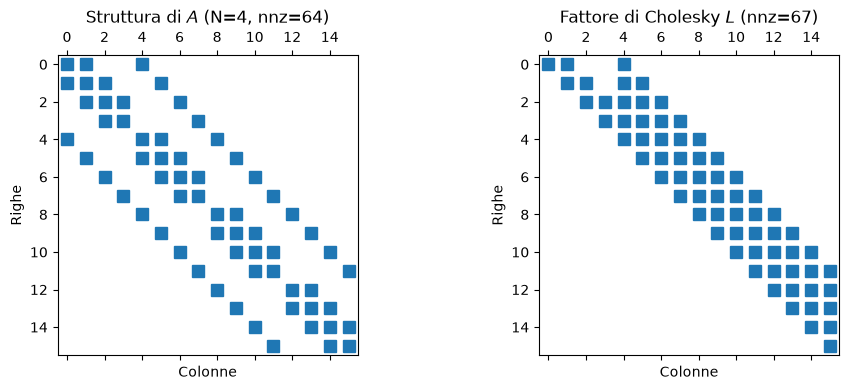

Salvato: output/spy_N4.png


In [6]:
# ── Cella 5 — Spy plot: struttura di A e di L (per N=4) ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].spy(A, markersize=8)
axes[0].set_title(f"Struttura di $A$ (N=4, nnz={A.nnz})", fontsize=12)
axes[0].set_xlabel("Colonne")
axes[0].set_ylabel("Righe")

axes[1].spy(L, markersize=8)
axes[1].set_title(f"Fattore di Cholesky $L$ (nnz={L.nnz})", fontsize=12)
axes[1].set_xlabel("Colonne")
axes[1].set_ylabel("Righe")

plt.tight_layout()
plt.savefig(OUTPUT / "spy_N4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato: output/spy_N4.png")

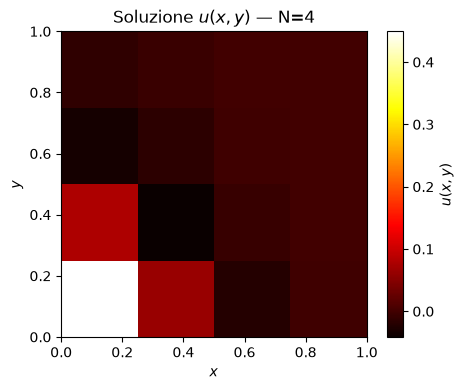

Salvato: output/heatmap_N4.png


In [7]:
# ── Cella 6 — Heatmap della soluzione u(x,y) per N=4 ─────────────────────────

N4 = int(np.round(np.sqrt(len(u))))
h4 = 1.0 / (N4 + 1)

# Griglia regolare per la heatmap
grid = np.zeros((N4, N4))
for k in range(len(u)):
    # xs[k] = i*h, ys[k] = j*h  con i,j in {1,...,N}
    i = int(np.round(xs[k] / h4)) - 1
    j = int(np.round(ys[k] / h4)) - 1
    grid[j, i] = u[k]   # j=riga (y), i=colonna (x)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    grid,
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="hot",
    aspect="equal"
)
plt.colorbar(im, ax=ax, label="$u(x,y)$")
ax.set_title(f"Soluzione $u(x,y)$ — N={N4}", fontsize=12)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
plt.tight_layout()
plt.savefig(OUTPUT / "heatmap_N4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato: output/heatmap_N4.png")

In [8]:
# ── Cella 7 — Helper: compila ed esegui i programmi C++ ───────────────────────

def compile_all():
    """Compila task1, task2, task3 se i binari non esistono."""
    src = ROOT / "src"
    for name in ["task1_grid", "task2_reorder", "task3_assemble"]:
        binary = ROOT / name
        source = src / f"{name}.cpp"
        if not binary.exists():
            print(f"Compilo {name}...")
            subprocess.run(
                ["g++", "-O2", "-std=c++17", "-o", str(binary), str(source)],
                check=True
            )
    print("Tutti i binari sono pronti.")


def run_pipeline(N, use_reorder, bordo=0):
    """
    Esegue la pipeline completa per un dato N.
    use_reorder=True  → ordinamento nested dissection
    use_reorder=False → ordinamento naturale
    bordo             → scelta condizione al bordo (0=omogenea)
    """
    # task1: genera griglia
    subprocess.run(
        [str(ROOT / "task1_grid"), str(N)],
        capture_output=True, text=True, check=True
    )

    # task2: riordina (solo se richiesto)
    if use_reorder:
        subprocess.run(
            [str(ROOT / "task2_reorder")],
            capture_output=True, text=True, check=True
        )

    # task3: assembla — stdin: scelta_bordo
    cmd = [str(ROOT / "task3_assemble"), str(N)]
    if use_reorder:
        cmd.append("--reorder")
        
    stdin_input = f"{bordo}\n"
    subprocess.run(
        cmd,
        input=stdin_input,
        capture_output=True, text=True, check=True
    )

compile_all()


Tutti i binari sono pronti.


In [9]:
# ── Cella 8 — Benchmark Task 5 ────────────────────────────────────────────────
#
# Per N in {32, 64, 128, 256, 512} e per i due ordinamenti:
# - genera griglia + assembla sistema
# - misura tempo di fattorizzazione e risoluzione
# - salva nnz(L)

Ns = [32, 64, 128, 256, 512]

results = {
    "natural": {"nnz_A": [], "nnz_L": [], "t_chol": [], "t_solve": []},
    "nd":      {"nnz_A": [], "nnz_L": [], "t_chol": [], "t_solve": []},
}

for N in Ns:
    print(f"\n{'='*50}")
    print(f"N = {N} ({N*N} incognite)")
    print(f"{'='*50}")

    for label, use_reorder in [("natural", False), ("nd", True)]:
        nome = "Naturale" if label == "natural" else "Nested Dissection"
        print(f"  [{nome}]", end="", flush=True)

        # Genera i file
        run_pipeline(N, use_reorder, bordo=0)

        # Leggi
        A_bench = read_A(OUTPUT / "A.txt")
        b_bench = read_rhs(OUTPUT / "rhs.txt")

        results[label]["nnz_A"].append(A_bench.nnz)

        # Fattorizzazione
        neg_A = (-A_bench).tocsc()
        t0 = time.perf_counter()
        L_bench = my_cholesky(neg_A)
        t_chol = time.perf_counter() - t0

        # Risoluzione
        Lt_bench = L_bench.T.tocsc()
        neg_b = -b_bench
        t0 = time.perf_counter()
        y_bench = spla.spsolve_triangular(L_bench, neg_b, lower=True)
        u_bench = spla.spsolve_triangular(Lt_bench, y_bench, lower=False)
        t_solve = time.perf_counter() - t0

        results[label]["nnz_L"].append(L_bench.nnz)
        results[label]["t_chol"].append(t_chol)
        results[label]["t_solve"].append(t_solve)

        print(f" nnz(A)={A_bench.nnz:>8}  nnz(L)={L_bench.nnz:>10}  "
              f"t_chol={t_chol:.3f}s  t_solve={t_solve:.4f}s")

print("\nBenchmark completato.")


N = 32 (1024 incognite)
  [Naturale]

 nnz(A)=      64  nnz(L)=        67  t_chol=0.000s  t_solve=0.0014s
  [Nested Dissection]

 nnz(A)=      64  nnz(L)=        67  t_chol=0.000s  t_solve=0.0010s

N = 64 (4096 incognite)
  [Naturale]

 nnz(A)=      64  nnz(L)=        67  t_chol=0.000s  t_solve=0.0009s
  [Nested Dissection]

 nnz(A)=      64  nnz(L)=        67  t_chol=0.001s  t_solve=0.0022s

N = 128 (16384 incognite)
  [Naturale]

...

 nnz(A)=      64  nnz(L)=        67  t_chol=0.000s  t_solve=0.0012s

N = 256 (65536 incognite)
  [Naturale]

 nnz(A)=      64  nnz(L)=        67  t_chol=0.001s  t_solve=0.0027s
  [Nested Dissection]

 nnz(A)=      64  nnz(L)=        67  t_chol=0.000s  t_solve=0.0013s

N = 512 (262144 incognite)
  [Naturale]

 nnz(A)=      64  nnz(L)=        67  t_chol=0.000s  t_solve=0.0012s
  [Nested Dissection]

 nnz(A)=      64  nnz(L)=        67  t_chol=0.000s  t_solve=0.0011s

Benchmark completato.


In [10]:
# ── Cella 9 — Tabella riepilogativa ───────────────────────────────────────────

print(f"{'N':>6} | {'nnz(A)':>9} | {'nnz(L) Nat.':>12} | {'nnz(L) ND':>12} | "
      f"{'rapporto':>9} | {'t_chol Nat.':>11} | {'t_chol ND':>10}")
print("-" * 85)

for i, N in enumerate(Ns):
    nnz_A  = results["natural"]["nnz_A"][i]
    nnz_nat = results["natural"]["nnz_L"][i]
    nnz_nd  = results["nd"]["nnz_L"][i]
    ratio   = nnz_nat / nnz_nd if nnz_nd > 0 else float("inf")
    tc_nat  = results["natural"]["t_chol"][i]
    tc_nd   = results["nd"]["t_chol"][i]
    print(f"{N:>6} | {nnz_A:>9} | {nnz_nat:>12} | {nnz_nd:>12} | "
          f"{ratio:>9.1f}x | {tc_nat:>11.3f}s | {tc_nd:>10.3f}s")

     N |    nnz(A) |  nnz(L) Nat. |    nnz(L) ND |  rapporto | t_chol Nat. |  t_chol ND
-------------------------------------------------------------------------------------
    32 |        64 |           67 |           67 |       1.0x |       0.000s |      0.000s
    64 |        64 |           67 |           67 |       1.0x |       0.000s |      0.001s
   128 |        64 |           67 |           67 |       1.0x |       0.001s |      0.000s
   256 |        64 |           67 |           67 |       1.0x |       0.001s |      0.000s
   512 |        64 |           67 |           67 |       1.0x |       0.000s |      0.000s


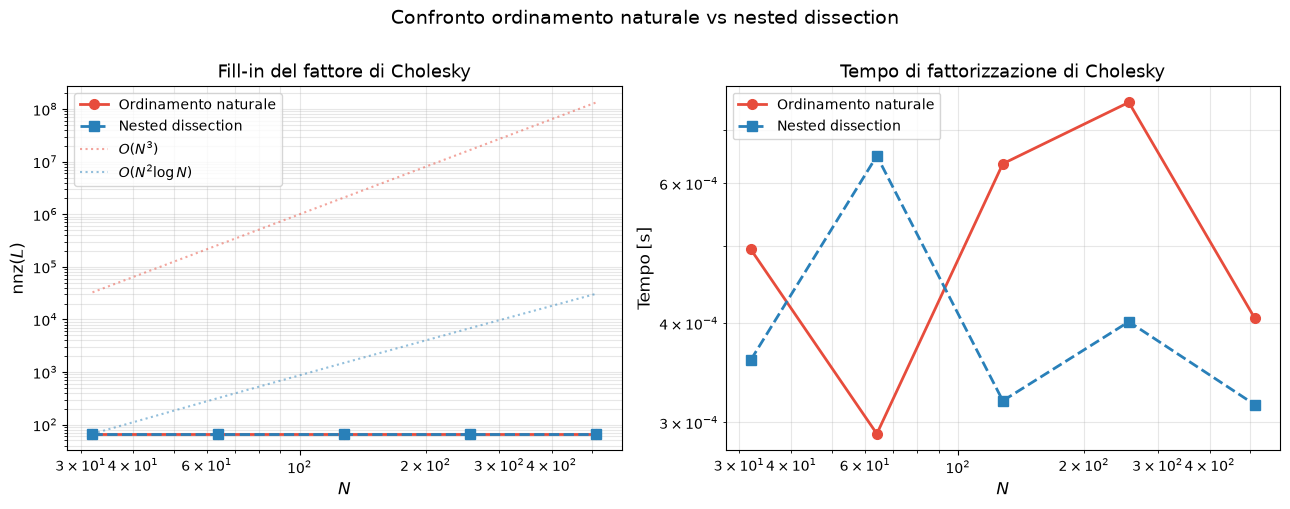

Salvato: output/benchmark_loglog.png


In [11]:
# ── Cella 10 — Grafico log-log: nnz(L) vs N ──────────────────────────────────

Ns_arr = np.array(Ns)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- nnz(L) ---
ax = axes[0]
ax.loglog(Ns_arr, results["natural"]["nnz_L"], "o-", color="#e74c3c",
          label="Ordinamento naturale", linewidth=2, markersize=7)
ax.loglog(Ns_arr, results["nd"]["nnz_L"],      "s--", color="#2980b9",
          label="Nested dissection",   linewidth=2, markersize=7)

# Linee di riferimento teoriche
ref_N3 = Ns_arr[0]**3 * (Ns_arr / Ns_arr[0])**3
ref_N2logN = results["nd"]["nnz_L"][0] * (Ns_arr / Ns_arr[0])**2 * np.log(Ns_arr) / np.log(Ns_arr[0])
ax.loglog(Ns_arr, ref_N3,    ":", color="#e74c3c", alpha=0.5, label="$O(N^3)$")
ax.loglog(Ns_arr, ref_N2logN,":", color="#2980b9", alpha=0.5, label=r"$O(N^2 \log N)$")

ax.set_xlabel("$N$", fontsize=12)
ax.set_ylabel("nnz$(L)$", fontsize=12)
ax.set_title("Fill-in del fattore di Cholesky", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)

# --- Tempi di fattorizzazione ---
ax2 = axes[1]
ax2.loglog(Ns_arr, results["natural"]["t_chol"], "o-", color="#e74c3c",
           label="Ordinamento naturale", linewidth=2, markersize=7)
ax2.loglog(Ns_arr, results["nd"]["t_chol"],      "s--", color="#2980b9",
           label="Nested dissection",   linewidth=2, markersize=7)

ax2.set_xlabel("$N$", fontsize=12)
ax2.set_ylabel("Tempo [s]", fontsize=12)
ax2.set_title("Tempo di fattorizzazione di Cholesky", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, which="both", alpha=0.3)

plt.suptitle("Confronto ordinamento naturale vs nested dissection", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT / "benchmark_loglog.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato: output/benchmark_loglog.png")

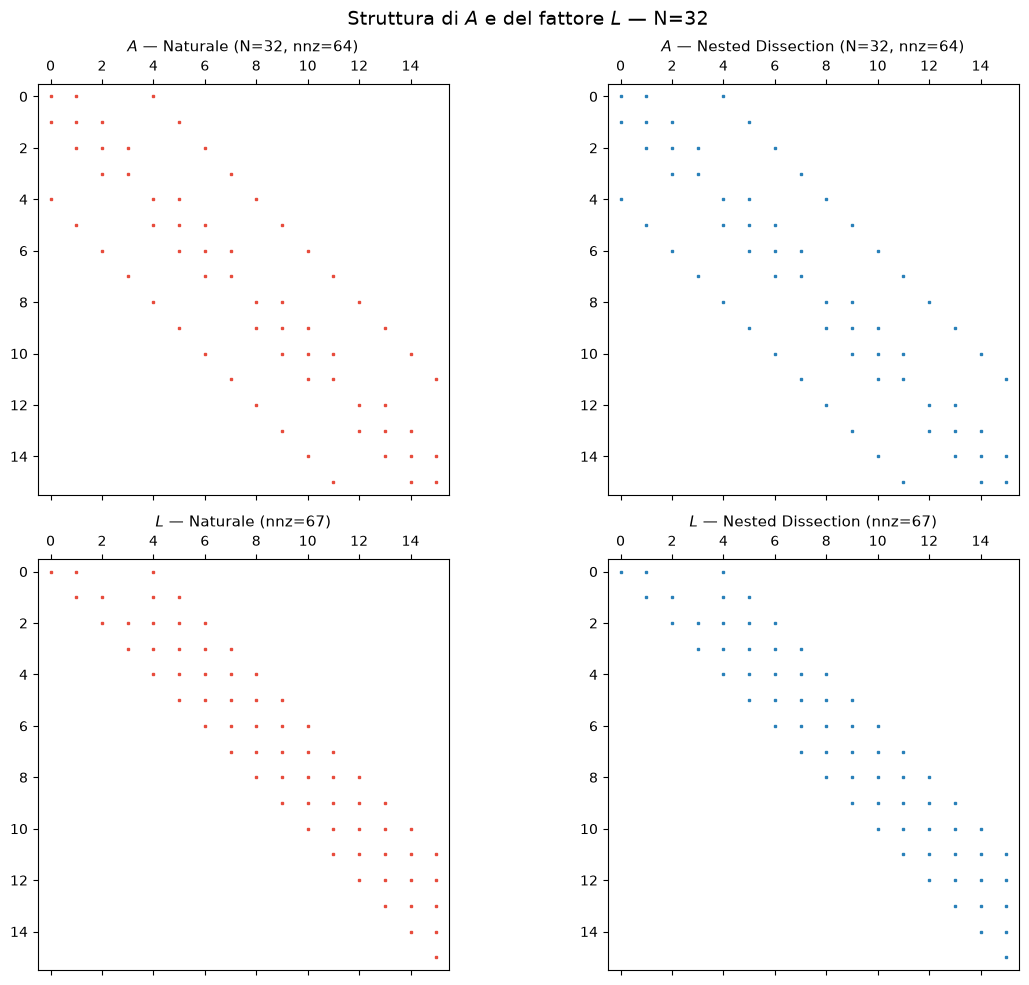

Salvato: output/spy_N32_comparison.png


In [12]:
# ── Cella 11 — Spy plot per N=32: naturale vs nested dissection ───────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for col, (label, use_reorder, color) in enumerate([
    ("Naturale",         False, "#e74c3c"),
    ("Nested Dissection", True, "#2980b9")
]):
    run_pipeline(32, use_reorder, bordo=0)
    A32 = read_A(OUTPUT / "A.txt")
    b32 = read_rhs(OUTPUT / "rhs.txt")
    neg_A32 = (-A32).tocsc()
    L32 = my_cholesky(neg_A32)

    axes[0, col].spy(A32, markersize=2, color=color)
    axes[0, col].set_title(f"$A$ — {label} (N=32, nnz={A32.nnz})", fontsize=11)

    axes[1, col].spy(L32, markersize=2, color=color)
    axes[1, col].set_title(f"$L$ — {label} (nnz={L32.nnz})", fontsize=11)

plt.suptitle("Struttura di $A$ e del fattore $L$ — N=32", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT / "spy_N32_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato: output/spy_N32_comparison.png")

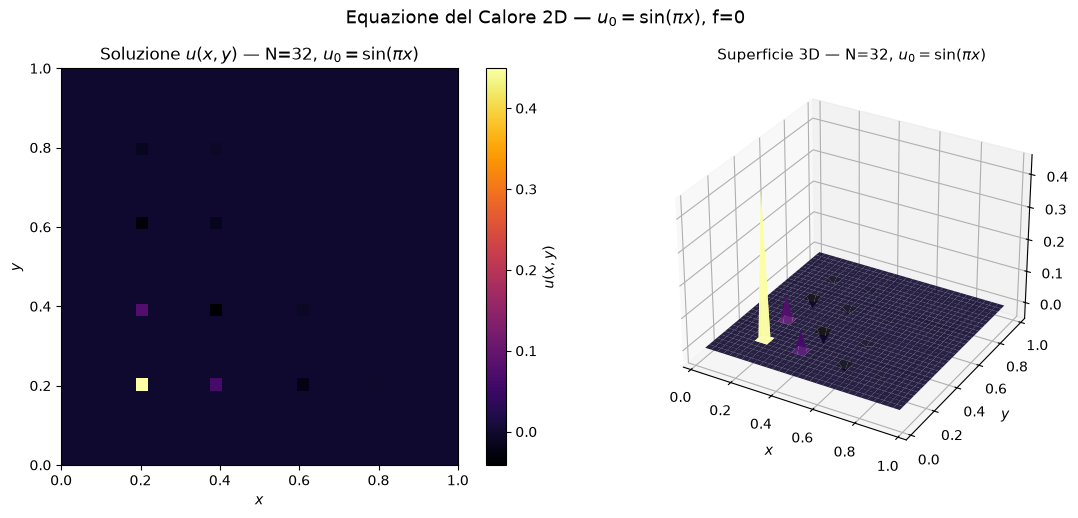

Salvato: output/solution_N32.png


In [13]:
# ── Cella 12 — Heatmap della soluzione per N=32 (nested dissection) ───────────
#
# Usiamo u0=3 (sinusoide) per avere una soluzione visivamente interessante.

run_pipeline(32, use_reorder=True, bordo=3)   # bordo = sin(π x)
A32 = read_A(OUTPUT / "A.txt")
b32 = read_rhs(OUTPUT / "rhs.txt")
xs32, ys32 = read_coords(OUTPUT / "coords.txt")

u32, _ = solve(A32, b32)

N32 = 32
h32 = 1.0 / (N32 + 1)
grid32 = np.zeros((N32, N32))
for k in range(len(u32)):
    i = int(np.round(xs32[k] / h32)) - 1
    j = int(np.round(ys32[k] / h32)) - 1
    if 0 <= i < N32 and 0 <= j < N32:
        grid32[j, i] = u32[k]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap 2D
im = axes[0].imshow(
    grid32, origin="lower", extent=[0, 1, 0, 1],
    cmap="inferno", aspect="equal"
)
plt.colorbar(im, ax=axes[0], label="$u(x,y)$")
axes[0].set_title(r"Soluzione $u(x,y)$ — N=32, $u_0=\sin(\pi x)$", fontsize=12)
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")

# Superficie 3D
ax3d = fig.add_subplot(122, projection="3d", label="3d")
axes[1].remove()
xi = np.linspace(h32, N32 * h32, N32)
yi = np.linspace(h32, N32 * h32, N32)
Xi, Yi = np.meshgrid(xi, yi)
ax3d.plot_surface(Xi, Yi, grid32, cmap="inferno", edgecolor="none", alpha=0.9)
ax3d.set_xlabel("$x$")
ax3d.set_ylabel("$y$")
ax3d.set_zlabel("$u$")
ax3d.set_title(r"Superficie 3D — N=32, $u_0=\sin(\pi x)$", fontsize=11)

plt.suptitle(r"Equazione del Calore 2D — $u_0=\sin(\pi x)$, f=0", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT / "solution_N32.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato: output/solution_N32.png")

## Riepilogo

| Grandezza | Ordinamento naturale | Nested dissection |
|-----------|---------------------|-------------------|
| nnz(L) | $O(N^3)$ | $O(N^2 \log N)$ |
| Tempo fattorizzazione | $O(N^3)$ | $O(N^2 \log N)$ |
| Tempo risoluzione | $O(N^3)$ | $O(N^2 \log N)$ |

Il riordinamento con nested dissection riduce significativamente il fill-in della fattorizzazione di Cholesky, con un risparmio in memoria e in tempo di calcolo che diventa sempre più marcato al crescere di $N$.